# Turkish Sentiment Benchmark for SIU 2026

This notebook evaluates two Turkish pretrained transformer models on three-class sentiment classification using a fixed 80/20 train-test split.

**Research questions**

- **RQ1.** Which pretrained Turkish transformer performs better on the same fixed split for three-class sentiment classification?
- **RQ2.** How sensitive are the results to the label boundary used for the negative and neutral classes?

**Models**

- BERTurk: `dbmdz/bert-base-turkish-cased`
- ConvBERTurk: `dbmdz/convbert-base-turkish-cased`

**Label schemes**

- **Scheme A:** negative = 1-3, neutral = 4-6, positive = 7-10
- **Scheme B:** negative = 1-4, neutral = 5-6, positive = 7-10

The notebook saves all intermediate artifacts to Google Drive, writes a reusable split file, and resumes incomplete training runs from the latest checkpoint.


In [1]:

# Environment preparation
import os
import sys
import subprocess

def _pip_install(packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "--force-reinstall"] + packages
    subprocess.check_call(cmd)

def _ensure_core_stack():
    try:
        import numpy as np
        import pandas as pd
        import sklearn
        import transformers
        import datasets
        import torch
        return False
    except Exception:
        _pip_install([
            "numpy==1.26.4",
            "pandas==2.2.2",
            "scipy==1.11.4",
            "scikit-learn==1.4.2",
            "matplotlib>=3.8.0",
            "transformers>=4.40.0",
            "datasets>=2.19.0",
            "accelerate>=0.30.0",
            "sentencepiece>=0.2.0",
        ])
        return True

_restart_required = _ensure_core_stack()
if _restart_required:
    print("Dependencies were refreshed. The runtime will restart now.")
    os.kill(os.getpid(), 9)


In [2]:

import os
import re
import gc
import json
import math
import time
import copy
import shutil
import random
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
)

from scipy.stats import chi2

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


numpy: 2.0.2
pandas: 2.2.2
torch: 2.10.0+cpu
cuda available: False


In [3]:

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [4]:

CONFIG = {
    "project_root": "/content/drive/MyDrive/SIU",
    "dataset_candidates": [
        "data/cleaned_movie_data_comment.csv",
        "cleaned_movie_data_comment.csv",
    ],
    "text_col": "comment_text",
    "rating_col": "comment_rating",
    "test_size": 0.20,
    "base_split_seed": 42,
    "run_seeds": [42, 43, 44],
    "num_labels": 3,
    "num_epochs": 3,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "train_batch_size": 16,
    "eval_batch_size": 32,
    "max_length": 256,
    "min_char_len": 5,
    "drop_duplicate_text_rating_pairs": True,
    "save_all_epoch_checkpoints": True,
    "resume_training": True,
    "force_recompute_completed_runs": False,
    "bootstrap_samples": 1000,
    "mixed_precision": True,
}

MODELS = {
    "BERTurk": "dbmdz/bert-base-turkish-cased",
    "ConvBERTurk": "dbmdz/convbert-base-turkish-cased",
}

LABEL_ID_TO_NAME = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

PROJECT_ROOT = Path(CONFIG["project_root"])
DATA_DIR = PROJECT_ROOT / "data"
REPRO_DIR = PROJECT_ROOT / "reproducibility"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "siu2026_turkish_sentiment_benchmark"

for path in [PROJECT_ROOT, DATA_DIR, REPRO_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

for subdir in [
    OUTPUT_DIR / "tables",
    OUTPUT_DIR / "figures",
    OUTPUT_DIR / "predictions",
    OUTPUT_DIR / "logs",
    OUTPUT_DIR / "runs",
    OUTPUT_DIR / "archives",
]:
    subdir.mkdir(parents=True, exist_ok=True)

display(pd.DataFrame([CONFIG]))


,project_root,dataset_candidates,text_col,rating_col,test_size,base_split_seed,run_seeds,num_labels,num_epochs,learning_rate,...,train_batch_size,eval_batch_size,max_length,min_char_len,drop_duplicate_text_rating_pairs,save_all_epoch_checkpoints,resume_training,force_recompute_completed_runs,bootstrap_samples,mixed_precision
0,/content/drive/MyDrive/SIU,"[data/cleaned_movie_data_comment.csv, cleaned_...",comment_text,comment_rating,0.2,42,"[42, 43, 44]",3,3,0.00002,...,16,32,256,5,True,True,True,False,1000,True


In [5]:

def resolve_dataset_path(project_root: Path, candidates):
    for rel_path in candidates:
        candidate = project_root / rel_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Dataset file was not found under the configured project directory. "
        "Expected one of: " + ", ".join(candidates)
    )

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_sample_id(text, rating_int):
    normalized = re.sub(r"\s+", " ", str(text)).strip()
    raw = f"{normalized}||{int(rating_int)}"
    return hashlib.sha256(raw.encode("utf-8")).hexdigest()

def set_all_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def load_json(path, default=None):
    path = Path(path)
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def safe_remove_dir(path):
    path = Path(path)
    if path.exists():
        shutil.rmtree(path)

def clone_dir(src, dst):
    src = Path(src)
    dst = Path(dst)
    safe_remove_dir(dst)
    shutil.copytree(src, dst)

def get_rng_state():
    state = {
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_random_state": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["torch_cuda_random_state_all"] = torch.cuda.get_rng_state_all()
    return state

def set_rng_state(state_dict):
    if not state_dict:
        return
    random.setstate(state_dict["python_random_state"])
    np.random.set_state(tuple(state_dict["numpy_random_state"]))
    torch.set_rng_state(state_dict["torch_random_state"])
    if torch.cuda.is_available() and "torch_cuda_random_state_all" in state_dict:
        torch.cuda.set_rng_state_all(state_dict["torch_cuda_random_state_all"])

def upsert_registry_row(row_dict, registry_path):
    registry_path = Path(registry_path)
    registry_path.parent.mkdir(parents=True, exist_ok=True)
    row_df = pd.DataFrame([row_dict])
    if registry_path.exists():
        old_df = pd.read_csv(registry_path)
        key_cols = ["scheme", "model", "seed"]
        mask = pd.Series([True] * len(old_df))
        for col in key_cols:
            if col in old_df.columns and col in row_df.columns:
                mask = mask & (old_df[col] == row_df.iloc[0][col])
        old_df = old_df.loc[~mask].copy()
        new_df = pd.concat([old_df, row_df], axis=0, ignore_index=True)
    else:
        new_df = row_df
    new_df.to_csv(registry_path, index=False)

DATASET_PATH = resolve_dataset_path(PROJECT_ROOT, CONFIG["dataset_candidates"])
print("Dataset path:", DATASET_PATH)


Dataset path: /content/drive/MyDrive/SIU/cleaned_movie_data_comment.csv


In [6]:

df_raw = pd.read_csv(DATASET_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

required_cols = [CONFIG["text_col"], CONFIG["rating_col"]]
missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df_raw.copy()
df[CONFIG["text_col"]] = df[CONFIG["text_col"]].map(normalize_text)
df[CONFIG["rating_col"]] = pd.to_numeric(df[CONFIG["rating_col"]], errors="coerce")

raw_rows = len(df)
df = df.dropna(subset=[CONFIG["text_col"], CONFIG["rating_col"]]).copy()
df = df[df[CONFIG["text_col"]].str.len() >= CONFIG["min_char_len"]].copy()
df = df[(df[CONFIG["rating_col"]] >= 1) & (df[CONFIG["rating_col"]] <= 10)].copy()
df["rating_int"] = df[CONFIG["rating_col"]].round().astype(int)

dedup_removed = 0
if CONFIG["drop_duplicate_text_rating_pairs"]:
    before = len(df)
    df = df.drop_duplicates(subset=[CONFIG["text_col"], "rating_int"]).copy()
    dedup_removed = before - len(df)

df = df.reset_index(drop=True)
df["row_id"] = np.arange(len(df), dtype=int)
df["sample_id"] = [
    build_sample_id(text, rating)
    for text, rating in zip(df[CONFIG["text_col"]], df["rating_int"])
]

if df["sample_id"].duplicated().any():
    raise ValueError("Duplicate sample_id values were found after preprocessing.")

audit_df = pd.DataFrame([{
    "dataset_path": str(DATASET_PATH),
    "raw_rows": int(raw_rows),
    "clean_rows": int(len(df)),
    "rows_removed_total": int(raw_rows - len(df)),
    "rows_removed_by_deduplication": int(dedup_removed),
    "min_char_len": int(CONFIG["min_char_len"]),
    "drop_duplicate_text_rating_pairs": bool(CONFIG["drop_duplicate_text_rating_pairs"]),
}])

display(audit_df)
display(df[[CONFIG["text_col"], CONFIG["rating_col"], "rating_int"]].head())

audit_df.to_csv(OUTPUT_DIR / "tables" / "dataset_audit.csv", index=False)
df.to_csv(OUTPUT_DIR / "tables" / "cleaned_snapshot_used_for_experiment.csv", index=False)


Raw shape: (23627, 6)


,movie_name,year,rating,genre,comment_text,comment_rating
0,Aya Seyahat,1902,8.1,Kısa Metraj,"i̇nsanlık için küçük, sinema için dev bir adım!",8.0
1,Aya Seyahat,1902,8.1,Kısa Metraj,"ay'a seyahat hakkında düşünüldüğünde, insanın ...",9.0
2,Aya Seyahat,1902,8.1,Kısa Metraj,film ile ilgili yazıda yönetmen tarafından eğl...,9.0
3,Aya Seyahat,1902,8.1,Kısa Metraj,aslında 1 asırı devirmiş olan bu film hakkında...,8.0
4,Aya Seyahat,1902,8.1,Kısa Metraj,hayal gücü ile olağanüstülüğün karıştığı bir f...,6.0


,dataset_path,raw_rows,clean_rows,rows_removed_total,rows_removed_by_deduplication,min_char_len,drop_duplicate_text_rating_pairs
0,/content/drive/MyDrive/SIU/cleaned_movie_data_...,23627,23605,22,19,5,True


,comment_text,comment_rating,rating_int
0,"i̇nsanlık için küçük, sinema için dev bir adım!",8.0,8
1,"ay'a seyahat hakkında düşünüldüğünde, insanın ...",9.0,9
2,film ile ilgili yazıda yönetmen tarafından eğl...,9.0,9
3,aslında 1 asırı devirmiş olan bu film hakkında...,8.0,8
4,hayal gücü ile olağanüstülüğün karıştığı bir f...,6.0,6


## Label schemes

In [7]:

def label_scheme_a(r):
    r = int(r)
    if r <= 3:
        return 0
    if r <= 6:
        return 1
    return 2

def label_scheme_b(r):
    r = int(r)
    if r <= 4:
        return 0
    if r <= 6:
        return 1
    return 2

LABEL_SCHEMES = {
    "scheme_A_1to3neg_4to6neu_7to10pos": label_scheme_a,
    "scheme_B_1to4neg_5to6neu_7to10pos": label_scheme_b,
}

for scheme_name, fn in LABEL_SCHEMES.items():
    df[scheme_name] = df["rating_int"].map(fn)

label_preview_cols = ["row_id", "sample_id", "rating_int"] + list(LABEL_SCHEMES.keys())
display(df[label_preview_cols].head(12))


,row_id,sample_id,rating_int,scheme_A_1to3neg_4to6neu_7to10pos,scheme_B_1to4neg_5to6neu_7to10pos
0,0,4f4f9397bee544c3bd2568569d1cd2d444a2b168513ee1...,8,2,2
1,1,7c82b7f908dbe2e97740634f13ccb70bf57051fd9f8f65...,9,2,2
2,2,947232318a8863f3033d443d5ea8c3a8ac2f10dd3f45cc...,9,2,2
3,3,448dad1a4ec0fad56c1d2d1ffb79f875c9da3620286ee4...,8,2,2
4,4,d2fff64b61ef96e0acf2c0ad67b2c758b36ba9343f3e35...,6,1,1
5,5,c83c06c65878de8190d60ce70fa90ed5a29bce46f2f95a...,9,2,2
6,6,6ca53f72bcdda7e52d7136550321dea6db49578a98dd40...,9,2,2
7,7,eba96db52bf68ec5e6d5a4e260995e8b8bd3ad7505e08c...,10,2,2
8,8,aa7d343b00d1bb60fd4afe3ffbaaee6fb2911a8fc8d021...,7,2,2
9,9,e345e515b0c136b08daae22725614c152cfeb6e43cadc5...,8,2,2


,scheme,label_id,label_name,count,ratio
0,scheme_A_1to3neg_4to6neu_7to10pos,0,negative,549,0.023258
1,scheme_A_1to3neg_4to6neu_7to10pos,1,neutral,1987,0.084177
2,scheme_A_1to3neg_4to6neu_7to10pos,2,positive,21069,0.892565
3,scheme_B_1to4neg_5to6neu_7to10pos,0,negative,834,0.035331
4,scheme_B_1to4neg_5to6neu_7to10pos,1,neutral,1702,0.072103
5,scheme_B_1to4neg_5to6neu_7to10pos,2,positive,21069,0.892565


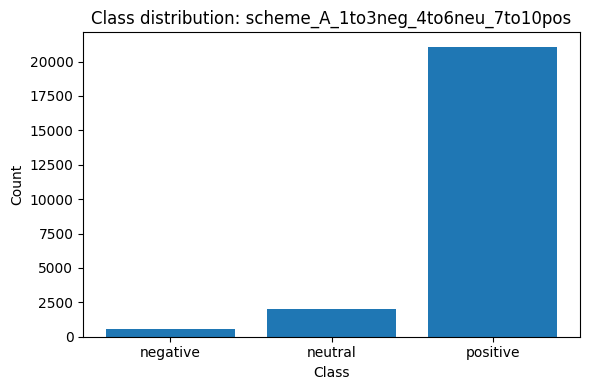

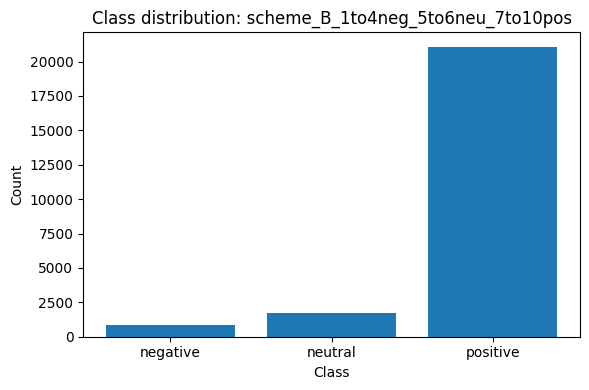

In [8]:

distribution_rows = []
for scheme_name in LABEL_SCHEMES.keys():
    counts = df[scheme_name].value_counts().sort_index()
    for label_id in range(CONFIG["num_labels"]):
        distribution_rows.append({
            "scheme": scheme_name,
            "label_id": label_id,
            "label_name": LABEL_ID_TO_NAME[label_id],
            "count": int(counts.get(label_id, 0)),
            "ratio": float(counts.get(label_id, 0) / len(df)),
        })

distribution_df = pd.DataFrame(distribution_rows)
display(distribution_df)
distribution_df.to_csv(OUTPUT_DIR / "tables" / "class_distributions.csv", index=False)

for scheme_name in LABEL_SCHEMES.keys():
    plot_df = distribution_df[distribution_df["scheme"] == scheme_name].copy()
    plt.figure(figsize=(6, 4))
    plt.bar(plot_df["label_name"], plot_df["count"])
    plt.title(f"Class distribution: {scheme_name}")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figures" / f"class_distribution_{scheme_name}.png", dpi=200)
    plt.show()


In [9]:

fingerprint = {
    "dataset_path": str(DATASET_PATH),
    "n_rows": int(len(df)),
    "text_col": CONFIG["text_col"],
    "rating_col": CONFIG["rating_col"],
    "min_char_len": int(CONFIG["min_char_len"]),
    "drop_duplicate_text_rating_pairs": bool(CONFIG["drop_duplicate_text_rating_pairs"]),
    "base_split_seed": int(CONFIG["base_split_seed"]),
    "fingerprint_sha256": hashlib.sha256(
        "\n".join(sorted(df["sample_id"].tolist())).encode("utf-8")
    ).hexdigest(),
}

save_json(fingerprint, REPRO_DIR / "dataset_fingerprint.json")
df[["sample_id", "row_id", CONFIG["text_col"], CONFIG["rating_col"], "rating_int"]].to_csv(
    REPRO_DIR / "sample_manifest.csv",
    index=False,
)

split_assignment_path = REPRO_DIR / "split_assignment.csv"
if split_assignment_path.exists():
    split_assignment = pd.read_csv(split_assignment_path)
    split_assignment["split"] = split_assignment["split"].astype(str).str.strip().str.lower()

    expected_cols = {"sample_id", "split"}
    if not expected_cols.issubset(split_assignment.columns):
        raise ValueError("split_assignment.csv must include sample_id and split columns.")

    missing_ids = set(df["sample_id"]) - set(split_assignment["sample_id"])
    extra_ids = set(split_assignment["sample_id"]) - set(df["sample_id"])
    if missing_ids:
        raise ValueError(f"split_assignment.csv does not cover the full dataset. Missing ids: {len(missing_ids)}")
    if extra_ids:
        raise ValueError(f"split_assignment.csv contains ids that are not present in the current dataset. Extra ids: {len(extra_ids)}")

    print("Existing split_assignment.csv was loaded from Drive.")
else:
    split_source = df[["sample_id", "rating_int"]].copy()
    train_part, test_part = train_test_split(
        split_source,
        test_size=CONFIG["test_size"],
        random_state=CONFIG["base_split_seed"],
        stratify=split_source["rating_int"],
    )
    split_assignment = pd.concat([
        pd.DataFrame({"sample_id": train_part["sample_id"], "split": "train"}),
        pd.DataFrame({"sample_id": test_part["sample_id"], "split": "test"}),
    ], axis=0).sort_values("sample_id").reset_index(drop=True)
    split_assignment.to_csv(split_assignment_path, index=False)
    print("A new split_assignment.csv was created and saved to Drive.")

df = df.merge(split_assignment, on="sample_id", how="left", validate="one_to_one")
if df["split"].isna().any():
    raise RuntimeError("Split assignment could not be merged back into the working dataset.")

base_train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
base_test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

split_info_df = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(base_train_df), len(base_test_df)],
    "ratio": [len(base_train_df) / len(df), len(base_test_df) / len(df)],
})
display(split_info_df)

split_info_df.to_csv(OUTPUT_DIR / "tables" / "base_split_info.csv", index=False)

for scheme_name in LABEL_SCHEMES.keys():
    scheme_dir = REPRO_DIR / scheme_name
    scheme_dir.mkdir(parents=True, exist_ok=True)

    train_export = base_train_df[
        ["sample_id", "row_id", CONFIG["text_col"], CONFIG["rating_col"], "rating_int", scheme_name]
    ].rename(columns={scheme_name: "label"})
    test_export = base_test_df[
        ["sample_id", "row_id", CONFIG["text_col"], CONFIG["rating_col"], "rating_int", scheme_name]
    ].rename(columns={scheme_name: "label"})

    train_export.to_csv(scheme_dir / "train.csv", index=False)
    test_export.to_csv(scheme_dir / "test.csv", index=False)

print("Reproducibility files are ready under:", REPRO_DIR)


Existing split_assignment.csv was loaded from Drive.


,split,rows,ratio
0,train,18884,0.8
1,test,4721,0.2


Reproducibility files are ready under: /content/drive/MyDrive/SIU/reproducibility


In [10]:

class TextClassificationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, text_col, label_col, max_length):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.text_col = text_col
        self.label_col = label_col
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        encoded = self.tokenizer(
            str(row[self.text_col]),
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )
        encoded["labels"] = int(row[self.label_col])
        encoded["row_id"] = int(row["row_id"])
        encoded["sample_id"] = str(row["sample_id"])
        return encoded

class DynamicPaddingCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        labels = torch.tensor([f.pop("labels") for f in features], dtype=torch.long)
        row_ids = torch.tensor([f.pop("row_id") for f in features], dtype=torch.long)
        sample_ids = [f.pop("sample_id") for f in features]
        batch = self.tokenizer.pad(features, padding=True, return_tensors="pt")
        batch["labels"] = labels
        batch["row_id"] = row_ids
        batch["sample_id"] = sample_ids
        return batch

def build_dataloaders(train_df, test_df, tokenizer):
    train_dataset = TextClassificationDataset(
        train_df, tokenizer, CONFIG["text_col"], "label", CONFIG["max_length"]
    )
    test_dataset = TextClassificationDataset(
        test_df, tokenizer, CONFIG["text_col"], "label", CONFIG["max_length"]
    )
    collator = DynamicPaddingCollator(tokenizer)

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["train_batch_size"],
        shuffle=True,
        collate_fn=collator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=CONFIG["eval_batch_size"],
        shuffle=False,
        collate_fn=collator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, test_loader

def compute_class_weights(y_train):
    counts = pd.Series(y_train).value_counts().sort_index()
    total = counts.sum()
    weights = []
    for label_id in range(CONFIG["num_labels"]):
        c = counts.get(label_id, 1)
        weights.append(total / (CONFIG["num_labels"] * c))
    return torch.tensor(weights, dtype=torch.float32)

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
    }

def make_class_report(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=[LABEL_ID_TO_NAME[i] for i in range(CONFIG["num_labels"])],
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})

def save_confusion_outputs(y_true, y_pred, run_dir, stem):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{LABEL_ID_TO_NAME[i]}" for i in range(CONFIG["num_labels"])],
        columns=[f"pred_{LABEL_ID_TO_NAME[i]}" for i in range(CONFIG["num_labels"])],
    )
    cm_df.to_csv(run_dir / f"{stem}.csv")

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(stem.replace("_", " "))
    plt.colorbar()
    tick_positions = np.arange(CONFIG["num_labels"])
    tick_labels = [LABEL_ID_TO_NAME[i] for i in range(CONFIG["num_labels"])]
    plt.xticks(tick_positions, tick_labels, rotation=45)
    plt.yticks(tick_positions, tick_labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(run_dir / f"{stem}.png", dpi=200)
    plt.close()

def final_outputs_exist(run_dir):
    required = [
        run_dir / "final" / "metrics.json",
        run_dir / "final" / "predictions.csv",
        run_dir / "final" / "class_report.csv",
        run_dir / "final" / "confusion_matrix.csv",
        run_dir / "final" / "model" / "config.json",
    ]
    return all(path.exists() for path in required)


In [11]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def save_resume_checkpoint(run_dir, model, tokenizer, optimizer, scheduler, scaler, epoch_completed, history_rows):
    resume_dir = run_dir / "resume_checkpoint"
    temp_dir = run_dir / "_resume_checkpoint_tmp"
    safe_remove_dir(temp_dir)
    (temp_dir / "model").mkdir(parents=True, exist_ok=True)

    model.save_pretrained(temp_dir / "model")
    tokenizer.save_pretrained(temp_dir / "model")

    torch.save(
        {
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "epoch_completed": int(epoch_completed),
            "rng_state": get_rng_state(),
            "history_rows": history_rows,
        },
        temp_dir / "trainer_state.pt",
    )

    save_json(
        {
            "epoch_completed": int(epoch_completed),
            "saved_at_unix": float(time.time()),
            "history_rows_count": int(len(history_rows)),
        },
        temp_dir / "training_state.json",
    )

    safe_remove_dir(resume_dir)
    temp_dir.rename(resume_dir)

    if CONFIG["save_all_epoch_checkpoints"]:
        epoch_dir = run_dir / "checkpoints" / f"epoch_{epoch_completed:02d}"
        clone_dir(resume_dir, epoch_dir)

def load_resume_checkpoint(run_dir):
    resume_dir = run_dir / "resume_checkpoint"
    state_path = resume_dir / "trainer_state.pt"
    model_dir = resume_dir / "model"
    if not (state_path.exists() and model_dir.exists()):
        return None
    trainer_state = torch.load(state_path, map_location="cpu")
    return {
        "model_dir": model_dir,
        "trainer_state": trainer_state,
    }

def train_one_epoch(model, dataloader, optimizer, scheduler, scaler, class_weights):
    model.train()
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    running_loss = 0.0
    batches = 0
    use_amp = bool(torch.cuda.is_available() and CONFIG["mixed_precision"])
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    for batch in dataloader:
        sample_ids = batch.pop("sample_id")
        row_ids = batch.pop("row_id")
        labels = batch["labels"].to(DEVICE)
        inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != "labels"}

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.autocast(device_type=autocast_device, dtype=torch.float16):
                outputs = model(**inputs)
                loss = criterion(outputs.logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(**inputs)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        running_loss += float(loss.detach().cpu().item())
        batches += 1

        del sample_ids, row_ids, labels, inputs, outputs, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return running_loss / max(batches, 1)

@torch.no_grad()
def evaluate_model(model, dataloader):
    model.eval()
    all_row_ids = []
    all_sample_ids = []
    all_y_true = []
    all_y_pred = []
    all_probs = []

    for batch in dataloader:
        sample_ids = batch.pop("sample_id")
        row_ids = batch.pop("row_id")
        labels = batch["labels"].to(DEVICE)
        inputs = {k: v.to(DEVICE) for k, v in batch.items() if k != "labels"}

        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)

        all_row_ids.extend(row_ids.cpu().numpy().tolist())
        all_sample_ids.extend(sample_ids)
        all_y_true.extend(labels.cpu().numpy().tolist())
        all_y_pred.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

        del sample_ids, row_ids, labels, inputs, outputs, logits, probs, preds

    probs_array = np.asarray(all_probs)
    pred_df = pd.DataFrame({
        "sample_id": all_sample_ids,
        "row_id": all_row_ids,
        "y_true": all_y_true,
        "y_pred": all_y_pred,
    })
    for label_id in range(CONFIG["num_labels"]):
        pred_df[f"prob_{LABEL_ID_TO_NAME[label_id]}"] = probs_array[:, label_id]

    metrics = compute_metrics(pred_df["y_true"], pred_df["y_pred"])
    return metrics, pred_df


In [12]:

def run_single_experiment(scheme_name, model_name, model_ckpt, run_seed):
    run_dir = OUTPUT_DIR / "runs" / scheme_name / model_name / f"seed_{run_seed}"
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "checkpoints").mkdir(parents=True, exist_ok=True)
    (run_dir / "final").mkdir(parents=True, exist_ok=True)

    registry_path = OUTPUT_DIR / "logs" / "experiment_registry.csv"
    history_csv_path = run_dir / "training_history.csv"

    train_df = pd.read_csv(REPRO_DIR / scheme_name / "train.csv")
    test_df = pd.read_csv(REPRO_DIR / scheme_name / "test.csv")

    base_meta = {
        "scheme": scheme_name,
        "model": model_name,
        "seed": run_seed,
        "checkpoint": model_ckpt,
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "updated_at_unix": float(time.time()),
    }

    if final_outputs_exist(run_dir) and not CONFIG["force_recompute_completed_runs"]:
        metrics = load_json(run_dir / "final" / "metrics.json", default={})
        pred_df = pd.read_csv(run_dir / "final" / "predictions.csv")
        upsert_registry_row({**base_meta, "status": "completed_loaded_from_disk"}, registry_path)
        print(f"[SKIP] {scheme_name} | {model_name} | seed={run_seed}")
        return metrics, pred_df

    print("\n" + "=" * 100)
    print(f"Running {scheme_name} | {model_name} | seed={run_seed}")
    print("Checkpoint:", model_ckpt)

    set_all_seeds(run_seed)
    tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
    train_loader, test_loader = build_dataloaders(train_df, test_df, tokenizer)

    class_weights = compute_class_weights(train_df["label"].tolist())
    total_steps = max(len(train_loader) * CONFIG["num_epochs"], 1)
    warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

    resume_info = load_resume_checkpoint(run_dir) if CONFIG["resume_training"] else None
    history_rows = []
    start_epoch = 1

    if resume_info is not None:
        model = AutoModelForSequenceClassification.from_pretrained(
            resume_info["model_dir"],
            num_labels=CONFIG["num_labels"],
        )
        trainer_state = resume_info["trainer_state"]
        start_epoch = int(trainer_state["epoch_completed"]) + 1
        history_rows = trainer_state.get("history_rows", [])
        print(f"[RESUME] continuing from epoch {start_epoch}")
    else:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_ckpt,
            num_labels=CONFIG["num_labels"],
        )

    model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=bool(torch.cuda.is_available() and CONFIG["mixed_precision"]))

    if resume_info is not None:
        trainer_state = resume_info["trainer_state"]
        optimizer.load_state_dict(trainer_state["optimizer_state_dict"])
        if trainer_state.get("scheduler_state_dict") is not None:
            scheduler.load_state_dict(trainer_state["scheduler_state_dict"])
        if trainer_state.get("scaler_state_dict") is not None and scaler is not None:
            scaler.load_state_dict(trainer_state["scaler_state_dict"])
        set_rng_state(trainer_state.get("rng_state"))

    upsert_registry_row({**base_meta, "status": "training_started"}, registry_path)

    for epoch in range(start_epoch, CONFIG["num_epochs"] + 1):
        epoch_start = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, class_weights)
        epoch_minutes = (time.time() - epoch_start) / 60.0

        history_rows.append({
            "scheme": scheme_name,
            "model": model_name,
            "seed": run_seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "epoch_minutes": float(epoch_minutes),
        })
        pd.DataFrame(history_rows).to_csv(history_csv_path, index=False)

        save_resume_checkpoint(
            run_dir=run_dir,
            model=model,
            tokenizer=tokenizer,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch_completed=epoch,
            history_rows=history_rows,
        )

        upsert_registry_row(
            {**base_meta, "status": f"epoch_{epoch}_completed", "updated_at_unix": float(time.time())},
            registry_path,
        )
        print(f"Epoch {epoch}/{CONFIG['num_epochs']} - train_loss={train_loss:.4f} - minutes={epoch_minutes:.2f}")

    metrics, pred_df = evaluate_model(model, test_loader)
    metrics.update({
        "scheme": scheme_name,
        "model": model_name,
        "checkpoint": model_ckpt,
        "seed": run_seed,
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "num_epochs": int(CONFIG["num_epochs"]),
    })

    final_dir = run_dir / "final"
    final_dir.mkdir(parents=True, exist_ok=True)

    save_json(metrics, final_dir / "metrics.json")
    pred_df.to_csv(final_dir / "predictions.csv", index=False)

    class_report_df = make_class_report(pred_df["y_true"], pred_df["y_pred"])
    class_report_df.to_csv(final_dir / "class_report.csv", index=False)

    save_confusion_outputs(
        pred_df["y_true"],
        pred_df["y_pred"],
        final_dir,
        "confusion_matrix",
    )

    model.save_pretrained(final_dir / "model")
    tokenizer.save_pretrained(final_dir / "model")

    upsert_registry_row({**base_meta, "status": "completed", "updated_at_unix": float(time.time())}, registry_path)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return metrics, pred_df


## Main experiment loop

In [13]:
import os
from getpass import getpass

use_hf_token = input("Hugging Face token kullanmak ister misiniz? [e/h]: ").strip().lower()

if use_hf_token in {"e", "evet", "y", "yes"}:
    print("Token alma yolu: Hugging Face hesabı > Settings > Access Tokens > New token")
    print("Bu notebook için read veya fine-grained(read-only) yeterlidir.")
    hf_token = getpass("HF token'ı yapıştırın: ").strip()

    if not hf_token.startswith("hf_"):
        raise ValueError("Geçersiz token görünüyor. Token genelde 'hf_' ile başlar.")

    os.environ["HF_TOKEN"] = hf_token
    print("HF token runtime'a yüklendi. Token ekranda gösterilmez.")
else:
    print("Token kullanılmadan devam edilecek.")

Hugging Face token kullanmak ister misiniz? [e/h]: e
Token alma yolu: Hugging Face hesabı > Settings > Access Tokens > New token
Bu notebook için read veya fine-grained(read-only) yeterlidir.
HF token'ı yapıştırın: ··········
HF token runtime'a yüklendi. Token ekranda gösterilmez.


In [14]:

all_metrics_rows = []
all_prediction_frames = {}

for scheme_name in LABEL_SCHEMES.keys():
    for model_name, model_ckpt in MODELS.items():
        for run_seed in CONFIG["run_seeds"]:
            metrics, pred_df = run_single_experiment(
                scheme_name=scheme_name,
                model_name=model_name,
                model_ckpt=model_ckpt,
                run_seed=run_seed,
            )
            all_metrics_rows.append(metrics)
            all_prediction_frames[(scheme_name, model_name, run_seed)] = pred_df.copy()

summary_per_run_df = pd.DataFrame(all_metrics_rows).sort_values(
    ["scheme", "model", "seed"]
).reset_index(drop=True)

display(summary_per_run_df)
summary_per_run_df.to_csv(OUTPUT_DIR / "tables" / "summary_metrics_per_run.csv", index=False)

summary_agg_df = (
    summary_per_run_df
    .groupby(["scheme", "model", "checkpoint"], as_index=False)
    .agg(
        runs=("seed", "count"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        weighted_f1_mean=("weighted_f1", "mean"),
        weighted_f1_std=("weighted_f1", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
    )
    .sort_values(["scheme", "macro_f1_mean", "balanced_accuracy_mean"], ascending=[True, False, False])
    .reset_index(drop=True)
)

display(summary_agg_df)
summary_agg_df.to_csv(OUTPUT_DIR / "tables" / "summary_metrics_aggregated.csv", index=False)


[SKIP] scheme_A_1to3neg_4to6neu_7to10pos | BERTurk | seed=42
[SKIP] scheme_A_1to3neg_4to6neu_7to10pos | BERTurk | seed=43
[SKIP] scheme_A_1to3neg_4to6neu_7to10pos | BERTurk | seed=44
[SKIP] scheme_A_1to3neg_4to6neu_7to10pos | ConvBERTurk | seed=42
[SKIP] scheme_A_1to3neg_4to6neu_7to10pos | ConvBERTurk | seed=43
[SKIP] scheme_A_1to3neg_4to6neu_7to10pos | ConvBERTurk | seed=44
[SKIP] scheme_B_1to4neg_5to6neu_7to10pos | BERTurk | seed=42
[SKIP] scheme_B_1to4neg_5to6neu_7to10pos | BERTurk | seed=43
[SKIP] scheme_B_1to4neg_5to6neu_7to10pos | BERTurk | seed=44
[SKIP] scheme_B_1to4neg_5to6neu_7to10pos | ConvBERTurk | seed=42
[SKIP] scheme_B_1to4neg_5to6neu_7to10pos | ConvBERTurk | seed=43
[SKIP] scheme_B_1to4neg_5to6neu_7to10pos | ConvBERTurk | seed=44


,accuracy,macro_f1,weighted_f1,balanced_accuracy,mcc,scheme,model,checkpoint,seed,train_rows,test_rows,num_epochs
0,0.846219,0.588209,0.866797,0.655269,0.438447,scheme_A_1to3neg_4to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,42,18884,4721,3
1,0.851303,0.586277,0.870742,0.664587,0.450456,scheme_A_1to3neg_4to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,43,18884,4721,3
2,0.849608,0.580645,0.869685,0.662383,0.446274,scheme_A_1to3neg_4to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,44,18884,4721,3
3,0.858505,0.600740,0.876149,0.674861,0.469265,scheme_A_1to3neg_4to6neu_7to10pos,ConvBERTurk,dbmdz/convbert-base-turkish-cased,42,18884,4721,3
4,0.865495,0.601211,0.880878,0.662631,0.479532,scheme_A_1to3neg_4to6neu_7to10pos,ConvBERTurk,dbmdz/convbert-base-turkish-cased,43,18884,4721,3
5,0.855963,0.594474,0.873948,0.653872,0.461398,scheme_A_1to3neg_4to6neu_7to10pos,ConvBERTurk,dbmdz/convbert-base-turkish-cased,44,18884,4721,3
6,0.821436,0.562682,0.850476,0.667494,0.413863,scheme_B_1to4neg_5to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,42,18884,4721,3
7,0.839017,0.570455,0.862115,0.646684,0.423394,scheme_B_1to4neg_5to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,43,18884,4721,3
8,0.841347,0.577312,0.864404,0.654504,0.431588,scheme_B_1to4neg_5to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,44,18884,4721,3
9,0.855963,0.590972,0.874201,0.655575,0.453877,scheme_B_1to4neg_5to6neu_7to10pos,ConvBERTurk,dbmdz/convbert-base-turkish-cased,42,18884,4721,3


,scheme,model,checkpoint,runs,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std
0,scheme_A_1to3neg_4to6neu_7to10pos,ConvBERTurk,dbmdz/convbert-base-turkish-cased,3,0.859987,0.004936,0.598808,0.003761,0.876992,0.003541,0.663788,0.010542,0.470065,0.009093
1,scheme_A_1to3neg_4to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,3,0.849043,0.002588,0.585044,0.003930,0.869075,0.002042,0.660747,0.004870,0.445059,0.006096
2,scheme_B_1to4neg_5to6neu_7to10pos,ConvBERTurk,dbmdz/convbert-base-turkish-cased,3,0.850526,0.004906,0.587088,0.010309,0.870506,0.003404,0.656619,0.011213,0.448577,0.008558
3,scheme_B_1to4neg_5to6neu_7to10pos,BERTurk,dbmdz/bert-base-turkish-cased,3,0.833933,0.010886,0.570150,0.007319,0.858998,0.007469,0.656227,0.010511,0.422949,0.008871


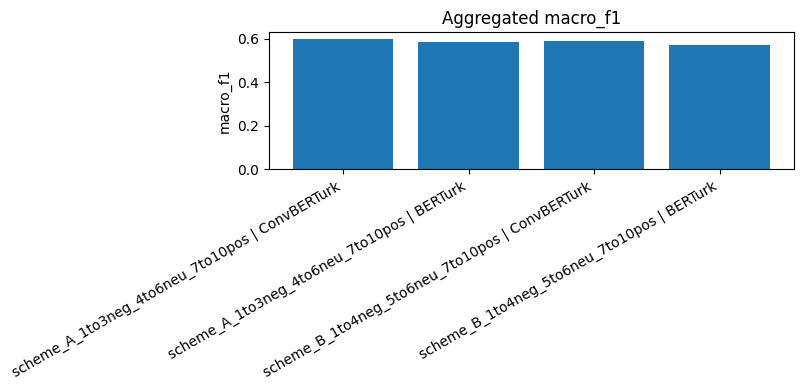

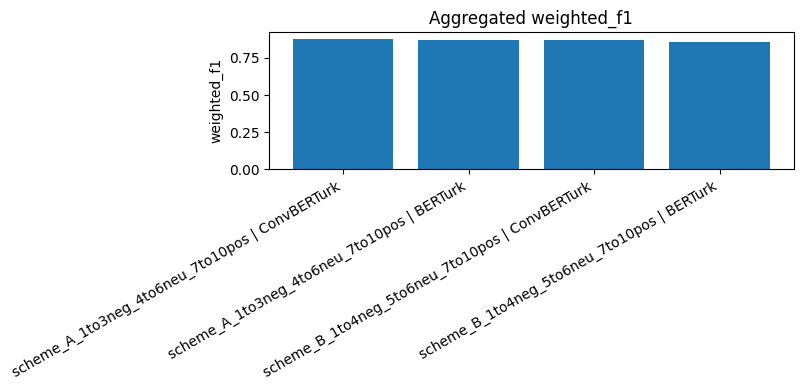

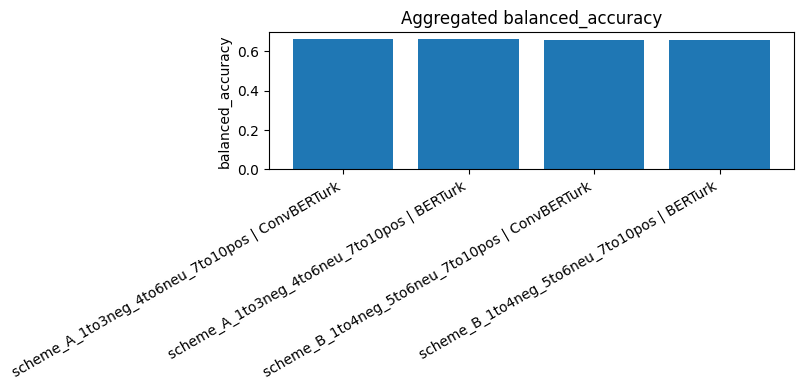

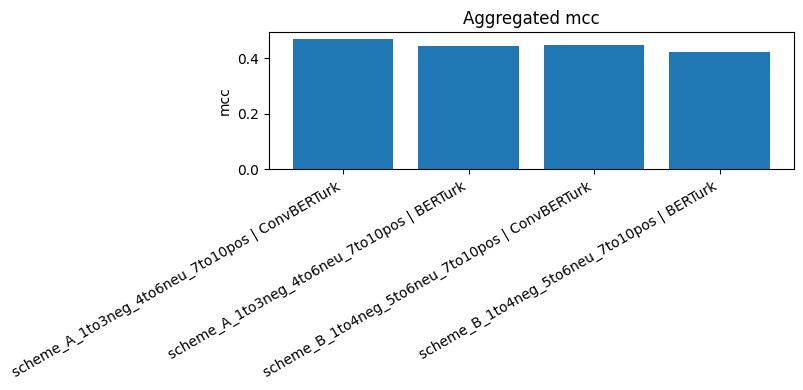

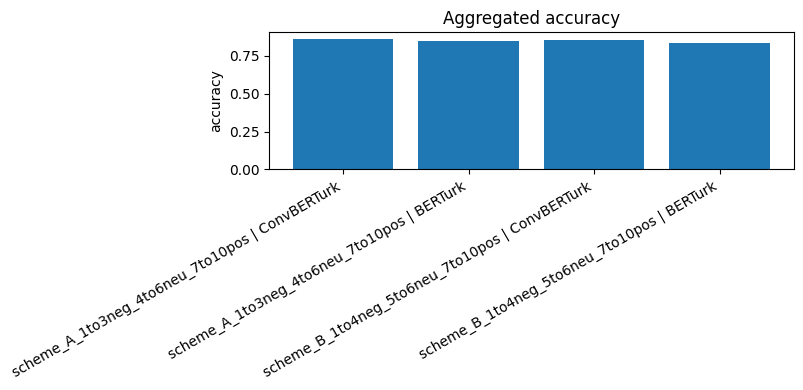

In [15]:

for metric_name in ["macro_f1", "weighted_f1", "balanced_accuracy", "mcc", "accuracy"]:
    plot_df = summary_agg_df.copy()
    plt.figure(figsize=(8, 4))
    x_labels = plot_df["scheme"] + " | " + plot_df["model"]
    plt.bar(x_labels, plot_df[f"{metric_name}_mean"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric_name)
    plt.title(f"Aggregated {metric_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figures" / f"aggregated_{metric_name}.png", dpi=200)
    plt.show()


In [16]:

def paired_bootstrap_metric_diff(y_true, pred_a, pred_b, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    n = len(y_true)
    diffs = []

    for _ in range(n_boot):
        indices = rng.integers(0, n, size=n)
        score_a = metric_fn(y_true[indices], pred_a[indices])
        score_b = metric_fn(y_true[indices], pred_b[indices])
        diffs.append(score_a - score_b)

    diffs = np.asarray(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_value = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return {
        "mean_diff": float(diffs.mean()),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "p_value": float(p_value),
    }

def macro_f1_fn(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def weighted_f1_fn(y_true, y_pred):
    return f1_score(y_true, y_pred, average="weighted", zero_division=0)

def mcnemar_test(y_true, pred_a, pred_b):
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    b = np.sum(a_correct & (~b_correct))
    c = np.sum((~a_correct) & b_correct)

    if (b + c) == 0:
        return {"b": int(b), "c": int(c), "chi2": 0.0, "p_value": 1.0}

    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - chi2.cdf(chi2_stat, df=1)
    return {"b": int(b), "c": int(c), "chi2": float(chi2_stat), "p_value": float(p_value)}


## Statistical comparisons

In [17]:

stats_rows = []

for scheme_name in LABEL_SCHEMES.keys():
    for run_seed in CONFIG["run_seeds"]:
        left_df = all_prediction_frames[(scheme_name, "BERTurk", run_seed)].sort_values("sample_id").reset_index(drop=True)
        right_df = all_prediction_frames[(scheme_name, "ConvBERTurk", run_seed)].sort_values("sample_id").reset_index(drop=True)

        if not np.array_equal(left_df["sample_id"].to_numpy(), right_df["sample_id"].to_numpy()):
            raise RuntimeError(f"Sample order mismatch for RQ1: {scheme_name}, seed={run_seed}")

        y_true = left_df["y_true"].to_numpy()
        pred_left = left_df["y_pred"].to_numpy()
        pred_right = right_df["y_pred"].to_numpy()

        macro_boot = paired_bootstrap_metric_diff(
            y_true, pred_left, pred_right, macro_f1_fn,
            n_boot=CONFIG["bootstrap_samples"], seed=run_seed
        )
        weighted_boot = paired_bootstrap_metric_diff(
            y_true, pred_left, pred_right, weighted_f1_fn,
            n_boot=CONFIG["bootstrap_samples"], seed=run_seed
        )
        mcnemar = mcnemar_test(y_true, pred_left, pred_right)

        stats_rows.append({
            "comparison_type": "RQ1_model_comparison",
            "scheme": scheme_name,
            "seed": run_seed,
            "left": "BERTurk",
            "right": "ConvBERTurk",
            "macro_f1_diff_left_minus_right": macro_boot["mean_diff"],
            "macro_f1_ci_low": macro_boot["ci_low"],
            "macro_f1_ci_high": macro_boot["ci_high"],
            "macro_f1_p_value": macro_boot["p_value"],
            "weighted_f1_diff_left_minus_right": weighted_boot["mean_diff"],
            "weighted_f1_ci_low": weighted_boot["ci_low"],
            "weighted_f1_ci_high": weighted_boot["ci_high"],
            "weighted_f1_p_value": weighted_boot["p_value"],
            "mcnemar_b": mcnemar["b"],
            "mcnemar_c": mcnemar["c"],
            "mcnemar_chi2": mcnemar["chi2"],
            "mcnemar_p_value": mcnemar["p_value"],
        })

for model_name in MODELS.keys():
    for run_seed in CONFIG["run_seeds"]:
        left_df = all_prediction_frames[("scheme_A_1to3neg_4to6neu_7to10pos", model_name, run_seed)].sort_values("sample_id").reset_index(drop=True)
        right_df = all_prediction_frames[("scheme_B_1to4neg_5to6neu_7to10pos", model_name, run_seed)].sort_values("sample_id").reset_index(drop=True)

        if not np.array_equal(left_df["sample_id"].to_numpy(), right_df["sample_id"].to_numpy()):
            raise RuntimeError(f"Sample order mismatch for RQ2: {model_name}, seed={run_seed}")

        y_true_left = left_df["y_true"].to_numpy()
        y_true_right = right_df["y_true"].to_numpy()
        pred_left = left_df["y_pred"].to_numpy()
        pred_right = right_df["y_pred"].to_numpy()

        if not np.array_equal(left_df["sample_id"].to_numpy(), right_df["sample_id"].to_numpy()):
            raise RuntimeError(f"Sample order mismatch for RQ2: {model_name}, seed={run_seed}")

        if not np.array_equal(left_df["row_id"].to_numpy(), right_df["row_id"].to_numpy()):
            raise RuntimeError(f"Row order mismatch for RQ2: {model_name}, seed={run_seed}")

        macro_scheme_a = f1_score(y_true_left, pred_left, average="macro", zero_division=0)
        macro_scheme_b = f1_score(y_true_right, pred_right, average="macro", zero_division=0)
        weighted_scheme_a = f1_score(y_true_left, pred_left, average="weighted", zero_division=0)
        weighted_scheme_b = f1_score(y_true_right, pred_right, average="weighted", zero_division=0)

        stats_rows.append({
            "comparison_type": "RQ2_scheme_sensitivity",
            "scheme": "scheme_A_vs_scheme_B",
            "seed": run_seed,
            "left": "scheme_A",
            "right": "scheme_B",
            "model": model_name,
            "macro_f1_scheme_A": float(macro_scheme_a),
            "macro_f1_scheme_B": float(macro_scheme_b),
            "macro_f1_diff_left_minus_right": float(macro_scheme_a - macro_scheme_b),
            "weighted_f1_scheme_A": float(weighted_scheme_a),
            "weighted_f1_scheme_B": float(weighted_scheme_b),
            "weighted_f1_diff_left_minus_right": float(weighted_scheme_a - weighted_scheme_b),
        })

stats_df = pd.DataFrame(stats_rows)
display(stats_df)
stats_df.to_csv(OUTPUT_DIR / "tables" / "statistical_comparisons.csv", index=False)


,comparison_type,scheme,seed,left,right,macro_f1_diff_left_minus_right,macro_f1_ci_low,macro_f1_ci_high,macro_f1_p_value,weighted_f1_diff_left_minus_right,...,weighted_f1_p_value,mcnemar_b,mcnemar_c,mcnemar_chi2,mcnemar_p_value,model,macro_f1_scheme_A,macro_f1_scheme_B,weighted_f1_scheme_A,weighted_f1_scheme_B
0,RQ1_model_comparison,scheme_A_1to3neg_4to6neu_7to10pos,42,BERTurk,ConvBERTurk,-0.012524,-0.033461,0.008298,0.252,-0.009416,...,0.002,147.0,205.0,9.230114,2.380669e-03,NaN,NaN,NaN,NaN,NaN
1,RQ1_model_comparison,scheme_A_1to3neg_4to6neu_7to10pos,43,BERTurk,ConvBERTurk,-0.015031,-0.036802,0.006606,0.172,-0.010100,...,0.002,123.0,190.0,13.916933,1.910694e-04,NaN,NaN,NaN,NaN,NaN
2,RQ1_model_comparison,scheme_A_1to3neg_4to6neu_7to10pos,44,BERTurk,ConvBERTurk,-0.013846,-0.035651,0.007175,0.224,-0.004165,...,0.144,151.0,181.0,2.533133,1.114787e-01,NaN,NaN,NaN,NaN,NaN
3,RQ1_model_comparison,scheme_B_1to4neg_5to6neu_7to10pos,42,BERTurk,ConvBERTurk,-0.028528,-0.047536,-0.010645,0.002,-0.023774,...,0.000,110.0,273.0,68.522193,1.110223e-16,NaN,NaN,NaN,NaN,NaN
4,RQ1_model_comparison,scheme_B_1to4neg_5to6neu_7to10pos,43,BERTurk,ConvBERTurk,-0.025140,-0.043786,-0.004961,0.020,-0.007872,...,0.008,145.0,193.0,6.535503,1.057423e-02,NaN,NaN,NaN,NaN,NaN
5,RQ1_model_comparison,scheme_B_1to4neg_5to6neu_7to10pos,44,BERTurk,ConvBERTurk,0.002522,-0.017785,0.021961,0.818,-0.002987,...,0.292,168.0,192.0,1.469444,2.254334e-01,NaN,NaN,NaN,NaN,NaN
6,RQ2_scheme_sensitivity,scheme_A_vs_scheme_B,42,scheme_A,scheme_B,0.025527,NaN,NaN,NaN,0.016322,...,NaN,NaN,NaN,NaN,NaN,BERTurk,0.588209,0.562682,0.866797,0.850476
7,RQ2_scheme_sensitivity,scheme_A_vs_scheme_B,43,scheme_A,scheme_B,0.015822,NaN,NaN,NaN,0.008626,...,NaN,NaN,NaN,NaN,NaN,BERTurk,0.586277,0.570455,0.870742,0.862115
8,RQ2_scheme_sensitivity,scheme_A_vs_scheme_B,44,scheme_A,scheme_B,0.003334,NaN,NaN,NaN,0.005282,...,NaN,NaN,NaN,NaN,NaN,BERTurk,0.580645,0.577312,0.869685,0.864404
9,RQ2_scheme_sensitivity,scheme_A_vs_scheme_B,42,scheme_A,scheme_B,0.009768,NaN,NaN,NaN,0.001948,...,NaN,NaN,NaN,NaN,NaN,ConvBERTurk,0.600740,0.590972,0.876149,0.874201


In [18]:

best_row = summary_agg_df.sort_values(
    ["macro_f1_mean", "balanced_accuracy_mean", "mcc_mean"],
    ascending=False
).iloc[0]

best_scheme = best_row["scheme"]
best_model = best_row["model"]
best_seed = CONFIG["run_seeds"][0]

best_pred_df = all_prediction_frames[(best_scheme, best_model, best_seed)].copy()
best_pred_df["confidence"] = best_pred_df[
    [f"prob_{LABEL_ID_TO_NAME[i]}" for i in range(CONFIG["num_labels"])]
].max(axis=1)

best_error_df = (
    best_pred_df[best_pred_df["y_true"] != best_pred_df["y_pred"]]
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

best_pred_df.to_csv(OUTPUT_DIR / "tables" / "best_configuration_predictions.csv", index=False)
best_error_df.to_csv(OUTPUT_DIR / "tables" / "best_configuration_top_errors.csv", index=False)

display(best_row.to_frame().T)
display(best_error_df.head(20))


,scheme,model,checkpoint,runs,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std
0,scheme_A_1to3neg_4to6neu_7to10pos,ConvBERTurk,dbmdz/convbert-base-turkish-cased,3,0.859987,0.004936,0.598808,0.003761,0.876992,0.003541,0.663788,0.010542,0.470065,0.009093


,sample_id,row_id,y_true,y_pred,prob_negative,prob_neutral,prob_positive,confidence
0,84808a89ac3ad5984e69c1f943282c1d0f51cf30be8b01...,6219,1,2,0.006553,0.019962,0.973485,0.973485
1,158a7a84b54a1e5a222f169fa204bb6accf39593531299...,4711,1,2,0.007782,0.018942,0.973277,0.973277
2,2b760fbe6429a51712e83155249174cd4d2ebae3ccbc20...,2489,1,2,0.006588,0.020174,0.973238,0.973238
3,4714e88738038bcc5a0c70ec56e0ed4ac8841110e387ad...,17959,1,2,0.006607,0.020727,0.972666,0.972666
4,00bb1222f277579f250368c697560e4d157496feaa9a77...,3938,1,2,0.006685,0.020980,0.972335,0.972335
5,8d903e934935e7d0f1b30a1bbbea3a28601181f50fd9b2...,6784,1,2,0.008432,0.021031,0.970536,0.970536
6,b6ea530bc203dc4d5791c7266168eee8b03cf109eb5bcb...,12216,1,2,0.006780,0.022871,0.970349,0.970349
7,fb174f2e7dfd166326abc816c036be8c70b9c53c77631b...,1766,1,2,0.006117,0.025407,0.968476,0.968476
8,ea28ea302d0d44b82f363b9f1ffc0f63519bc8ac0055e3...,2726,1,2,0.005989,0.026505,0.967506,0.967506
9,e9f1a03df016691aee307c14dcae4d902808ff6f3cdc32...,15532,1,2,0.007588,0.025819,0.966593,0.966593


In [20]:

archive_base = OUTPUT_DIR / "archives" / "siu2026_turkish_sentiment_benchmark_outputs"
archive_path = shutil.make_archive(str(archive_base), "zip", root_dir=OUTPUT_DIR)

print("Archive created:", archive_path)
print("Output directory:", OUTPUT_DIR)
print("Reproducibility directory:", REPRO_DIR)


KeyboardInterrupt: 

## Notes

Files that should be kept together for exact split reproducibility:

- `reproducibility/split_assignment.csv`
- `reproducibility/dataset_fingerprint.json`
- `reproducibility/sample_manifest.csv`

If these files are committed with the dataset snapshot and the notebook, the same 80/20 split is reused across reruns and across different environments that use the same cleaned dataset.
